<a href="https://colab.research.google.com/github/waghvaishnav/Deep-Learning-PlayGround-Hub/blob/main/Model_Opt_in_Deep_Learning_Regularization_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving sonar.all-data to sonar.all-data


{'sonar.all-data': b'0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,0.1609,0.1582,0.2238,0.0645,0.0660,0.2273,0.3100,0.2999,0.5078,0.4797,0.5783,0.5071,0.4328,0.5550,0.6711,0.6415,0.7104,0.8080,0.6791,0.3857,0.1307,0.2604,0.5121,0.7547,0.8537,0.8507,0.6692,0.6097,0.4943,0.2744,0.0510,0.2834,0.2825,0.4256,0.2641,0.1386,0.1051,0.1343,0.0383,0.0324,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R\r\n0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,0.4918,0.6552,0.6919,0.7797,0.7464,0.9444,1.0000,0.8874,0.8024,0.7818,0.5212,0.4052,0.3957,0.3914,0.3250,0.3200,0.3271,0.2767,0.4423,0.2028,0.3788,0.2947,0.1984,0.2341,0.1306,0.4182,0.3835,0.1057,0.1840,0.1970,0.1674,0.0583,0.1401,0.1628,0.0621,0.0203,0.0530,0.0742,0.0409,0.0061,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R\r\n0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,0.6333,0.7060,0.5544,0.5320,0.6479,0.6931,0.6759,0.7551,0.8

In [3]:
import pandas as pd
data = pd.read_csv("sonar.all-data")
df = pd.DataFrame(data)

df.sample(2)

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
87,0.0274,0.0242,0.0621,0.0560,0.1129,0.0973,0.1823,0.1745,0.1440,0.1808,...,0.0113,0.0108,0.0085,0.0047,0.0074,0.0104,0.0161,0.0220,0.0173,R
190,0.0315,0.0252,0.0167,0.0479,0.0902,0.1057,0.1024,0.1209,0.1241,0.1533,...,0.0108,0.0062,0.0044,0.0072,0.0007,0.0054,0.0035,0.0001,0.0055,M


In [4]:
df["R"] = df["R"].map({"R":0,"M":1})
df.sample(2)

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
57,0.0225,0.0019,0.0075,0.0097,0.0445,0.0906,0.0889,0.0655,0.1624,0.1452,...,0.0034,0.0129,0.0100,0.0044,0.0057,0.0030,0.0035,0.0021,0.0027,0
162,0.0072,0.0027,0.0089,0.0061,0.0420,0.0865,0.1182,0.0999,0.1976,0.2318,...,0.0078,0.0071,0.0081,0.0034,0.0064,0.0037,0.0036,0.0012,0.0037,1


In [6]:
# importing required modules :

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset
import matplotlib.pyplot as plt


In [7]:
x = df.drop("R",axis=1)
y = df["R"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((165, 60), (42, 60), (165,), (42,))

In [17]:
x_train_tensor = torch.tensor(x_train.values,dtype=torch.float32)
x_test_tensor = torch.tensor(x_test.values,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.long)


In [18]:
train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
val_loader = DataLoader(test_dataset,batch_size=16,shuffle=False)

In [19]:
len(x)

207

## Define a Neural Network :

In [20]:
class SimpleNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(60,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,2)
    )
  def forward(self,x):
    return self.network(x)



In [21]:
def model_train(model,train_loader,val_loader,criterion,optimizer,epochs=20):

  train_loss,val_loss,val_accuracies = [],[],[]

  # model training :
  for epoch in range(epochs):
    model.train()
    run_loss = 0.00
    # forward pass :
    for inputs,labels in train_loader:
      output = model(inputs)
      loss = criterion(output,labels)

      # backward pass :
      optimizer.zero_grad()
      loss.backward()

      # weight updation :
      optimizer.step()

      run_loss += loss.item()
    train_loss.append(run_loss/len(train_loader))

      # model validation

    model.eval()

    v_loss = 0.00
    y_pred,y_true = [],[]

    with torch.no_grad():
      for input,labels in val_loader:
        output = model(input)
        loss = criterion(output,labels)
        _,predicted = torch.max(output.data,1)
        y_pred.extend(predicted.numpy())
        y_true.extend(labels.numpy())
    val_loss.append(loss.item()/len(val_loader))
    acc = accuracy_score(y_pred,y_true)
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Accuracy: {acc:.4f}")




  return train_loss,val_loss,val_accuracies



In [22]:
model = SimpleNN()
optimizer = optim.Adam(model.parameters(),lr=0.001)
criterion = nn.CrossEntropyLoss()

train_loss_without_drop,val_loss_without_dr,accuracies_without_dr = model_train(model,train_loader,val_loader,criterion,optimizer)

Epoch 1/20, Train Loss: 0.6942, Val Loss: 0.2321, Val Accuracy: 0.3571
Epoch 2/20, Train Loss: 0.6834, Val Loss: 0.2252, Val Accuracy: 0.6429
Epoch 3/20, Train Loss: 0.6706, Val Loss: 0.2178, Val Accuracy: 0.7619
Epoch 4/20, Train Loss: 0.6561, Val Loss: 0.2071, Val Accuracy: 0.8095
Epoch 5/20, Train Loss: 0.6387, Val Loss: 0.2063, Val Accuracy: 0.7143
Epoch 6/20, Train Loss: 0.5985, Val Loss: 0.1871, Val Accuracy: 0.7143
Epoch 7/20, Train Loss: 0.5679, Val Loss: 0.1873, Val Accuracy: 0.7143
Epoch 8/20, Train Loss: 0.5264, Val Loss: 0.1902, Val Accuracy: 0.6667
Epoch 9/20, Train Loss: 0.4689, Val Loss: 0.1732, Val Accuracy: 0.7619
Epoch 10/20, Train Loss: 0.4276, Val Loss: 0.1357, Val Accuracy: 0.8095
Epoch 11/20, Train Loss: 0.4250, Val Loss: 0.1563, Val Accuracy: 0.7857
Epoch 12/20, Train Loss: 0.3705, Val Loss: 0.1743, Val Accuracy: 0.7857
Epoch 13/20, Train Loss: 0.3681, Val Loss: 0.1513, Val Accuracy: 0.7857
Epoch 14/20, Train Loss: 0.3548, Val Loss: 0.2951, Val Accuracy: 0.5952
E

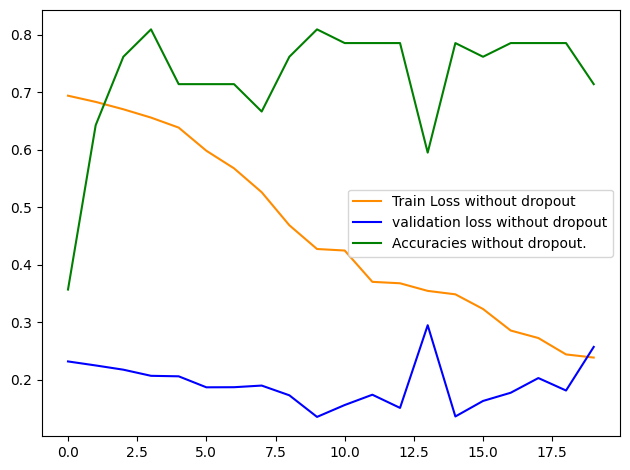

In [23]:
plt.plot(train_loss_without_drop,label = "Train Loss without dropout",color="darkorange")
plt.plot(val_loss_without_dr, label = "validation loss without dropout",color="blue")
plt.plot(accuracies_without_dr,label="Accuracies without dropout.",color="green")
plt.legend()
plt.tight_layout()

plt.show()

# Model With Dropout :

In [33]:
class DropoutModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(60,128),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(64,2)
    )
  def forward(self,x):
    return self.network(x)



Epoch 1/20, Train Loss: 0.7277, Val Loss: 0.2335, Val Accuracy: 0.4524
Epoch 2/20, Train Loss: 0.6673, Val Loss: 0.1949, Val Accuracy: 0.7143
Epoch 3/20, Train Loss: 0.6299, Val Loss: 0.1835, Val Accuracy: 0.7619
Epoch 4/20, Train Loss: 0.5673, Val Loss: 0.2738, Val Accuracy: 0.4762
Epoch 5/20, Train Loss: 0.5695, Val Loss: 0.1416, Val Accuracy: 0.7619
Epoch 6/20, Train Loss: 0.5627, Val Loss: 0.1305, Val Accuracy: 0.7857
Epoch 7/20, Train Loss: 0.5367, Val Loss: 0.2218, Val Accuracy: 0.6429
Epoch 8/20, Train Loss: 0.5592, Val Loss: 0.2516, Val Accuracy: 0.5952
Epoch 9/20, Train Loss: 0.5064, Val Loss: 0.1744, Val Accuracy: 0.7857
Epoch 10/20, Train Loss: 0.4701, Val Loss: 0.1764, Val Accuracy: 0.7857
Epoch 11/20, Train Loss: 0.4274, Val Loss: 0.2749, Val Accuracy: 0.6429
Epoch 12/20, Train Loss: 0.5158, Val Loss: 0.1691, Val Accuracy: 0.7619
Epoch 13/20, Train Loss: 0.4749, Val Loss: 0.1391, Val Accuracy: 0.8095
Epoch 14/20, Train Loss: 0.4588, Val Loss: 0.2107, Val Accuracy: 0.7619
E

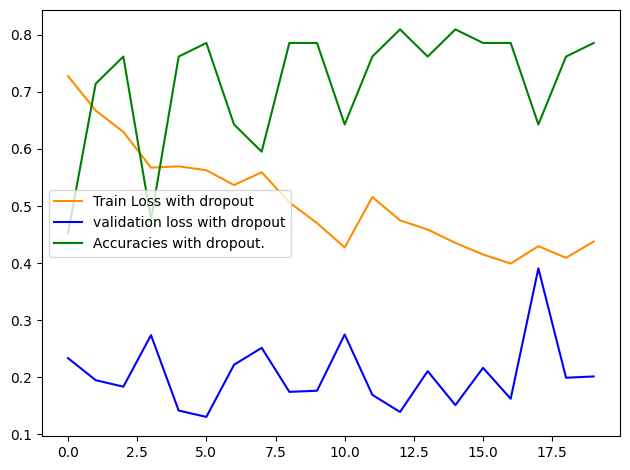

In [34]:
model = DropoutModel()
optimizer = optim.Adam(model.parameters(),lr=0.01)
criterion = nn.CrossEntropyLoss()

train_loss_with_drop,val_loss_with_dr,accuracies_with_dr = model_train(model,train_loader,val_loader,criterion,optimizer)


# graph visualization :

plt.plot(train_loss_with_drop,label = "Train Loss with dropout",color="darkorange")
plt.plot(val_loss_with_dr, label = "validation loss with dropout",color="blue")
plt.plot(accuracies_with_dr,label="Accuracies with dropout.",color="green")
plt.legend()
plt.tight_layout()

plt.show()

# L2 Regularization in Pytorch

In [35]:
class L2Regul(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(60,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,2)
    )
  def forward(self,x):
    return self.network(x)



Epoch 1/20, Train Loss: 0.6946, Val Loss: 0.2228, Val Accuracy: 0.6429
Epoch 2/20, Train Loss: 0.6923, Val Loss: 0.2245, Val Accuracy: 0.6429
Epoch 3/20, Train Loss: 0.6926, Val Loss: 0.2350, Val Accuracy: 0.3571
Epoch 4/20, Train Loss: 0.6905, Val Loss: 0.2290, Val Accuracy: 0.5000
Epoch 5/20, Train Loss: 0.6869, Val Loss: 0.2279, Val Accuracy: 0.5238
Epoch 6/20, Train Loss: 0.6853, Val Loss: 0.2274, Val Accuracy: 0.5238
Epoch 7/20, Train Loss: 0.6845, Val Loss: 0.2233, Val Accuracy: 0.6905
Epoch 8/20, Train Loss: 0.6849, Val Loss: 0.2293, Val Accuracy: 0.5714
Epoch 9/20, Train Loss: 0.6803, Val Loss: 0.2220, Val Accuracy: 0.6905
Epoch 10/20, Train Loss: 0.6778, Val Loss: 0.2135, Val Accuracy: 0.6429
Epoch 11/20, Train Loss: 0.6744, Val Loss: 0.2159, Val Accuracy: 0.7381
Epoch 12/20, Train Loss: 0.6702, Val Loss: 0.2215, Val Accuracy: 0.6190
Epoch 13/20, Train Loss: 0.6685, Val Loss: 0.2255, Val Accuracy: 0.5952
Epoch 14/20, Train Loss: 0.6640, Val Loss: 0.2168, Val Accuracy: 0.6905
E

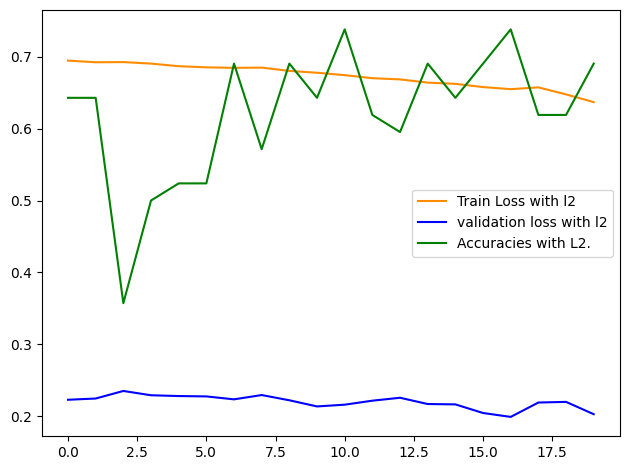

In [41]:
model_l2 = L2Regul()
optimizer = optim.SGD(model_l2.parameters(),lr=0.06,weight_decay=0.02)
criterion = nn.CrossEntropyLoss()

loss_with_l2,val_loss_with_l2,accuracies_with_l2 = model_train(model_l2,train_loader,val_loader,criterion,optimizer)


# graph visualization :

plt.plot(loss_with_l2,label = "Train Loss with l2",color="darkorange")
plt.plot(val_loss_with_l2, label = "validation loss with l2",color="blue")
plt.plot(accuracies_with_l2,label="Accuracies with L2.",color="green")
plt.legend()
plt.tight_layout()

plt.show()

# L1 Regularization :

In [42]:
class Regul_L1(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(60,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,2)
    )
  def forward(self,x):
    return self.network(x)



In [46]:
def model_train(model,train_loader,val_loader,criterion,optimizer,epochs=20):

  train_loss,val_loss,val_accuracies = [],[],[]

  # model training :
  for epoch in range(epochs):
    model.train()
    run_loss = 0.00

    lambda_l1 = 0.01

    # forward pass :
    for inputs,labels in train_loader:

      output = model(inputs)
      loss = criterion(output,labels)

      penalty = 0
      for params in model.parameters():
        penalty += torch.max(torch.abs(params))

      loss += lambda_l1 * penalty

      # backward pass :
      optimizer.zero_grad()
      loss.backward()

      # weight updation :
      optimizer.step()

      run_loss += loss.item()
    train_loss.append(run_loss/len(train_loader))

      # model validation

    model.eval()

    v_loss = 0.00
    y_pred,y_true = [],[]

    with torch.no_grad():
      for input,labels in val_loader:
        output = model(input)
        loss = criterion(output,labels)
        _,predicted = torch.max(output.data,1)
        y_pred.extend(predicted.numpy())
        y_true.extend(labels.numpy())
    val_loss.append(loss.item()/len(val_loader))
    acc = accuracy_score(y_pred,y_true)
    val_accuracies.append(acc)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Accuracy: {acc:.4f}")




  return train_loss,val_loss,val_accuracies



Epoch 1/20, Train Loss: 0.7013, Val Loss: 0.2398, Val Accuracy: 0.3571
Epoch 2/20, Train Loss: 0.7010, Val Loss: 0.2281, Val Accuracy: 0.6429
Epoch 3/20, Train Loss: 0.6976, Val Loss: 0.2295, Val Accuracy: 0.6429
Epoch 4/20, Train Loss: 0.6943, Val Loss: 0.2254, Val Accuracy: 0.6429
Epoch 5/20, Train Loss: 0.6947, Val Loss: 0.2279, Val Accuracy: 0.6429
Epoch 6/20, Train Loss: 0.6915, Val Loss: 0.2269, Val Accuracy: 0.6905
Epoch 7/20, Train Loss: 0.6924, Val Loss: 0.2284, Val Accuracy: 0.5476
Epoch 8/20, Train Loss: 0.6905, Val Loss: 0.2268, Val Accuracy: 0.6190
Epoch 9/20, Train Loss: 0.6877, Val Loss: 0.2241, Val Accuracy: 0.6905
Epoch 10/20, Train Loss: 0.6837, Val Loss: 0.2164, Val Accuracy: 0.6429
Epoch 11/20, Train Loss: 0.6872, Val Loss: 0.2239, Val Accuracy: 0.6190
Epoch 12/20, Train Loss: 0.6869, Val Loss: 0.2293, Val Accuracy: 0.5476
Epoch 13/20, Train Loss: 0.6810, Val Loss: 0.2220, Val Accuracy: 0.6429
Epoch 14/20, Train Loss: 0.6785, Val Loss: 0.2224, Val Accuracy: 0.5952
E

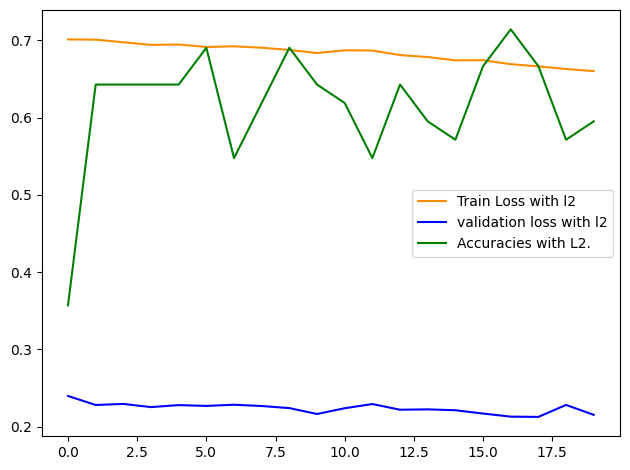

In [47]:
model_l2 = L2Regul()
optimizer = optim.SGD(model_l2.parameters(),lr=0.06,weight_decay=0.02)
criterion = nn.CrossEntropyLoss()

loss_with_l2,val_loss_with_l2,accuracies_with_l2 = model_train(model_l2,train_loader,val_loader,criterion,optimizer)


# graph visualization :

plt.plot(loss_with_l2,label = "Train Loss with l2",color="darkorange")
plt.plot(val_loss_with_l2, label = "validation loss with l2",color="blue")
plt.plot(accuracies_with_l2,label="Accuracies with L2.",color="green")
plt.legend()
plt.tight_layout()

plt.show()